# ⚙️ Predictive Maintenance — Multi-Scenario Inferences & Diagnostics

This notebook demonstrates **real-time failure diagnosis, what-if stress simulations, batch sensor stream evaluation, SHAP root-cause analysis, and MLflow registration** using the pretrained **Predictive Maintenance Model** (`predictive_maintenance_rf_model.joblib`).

---
### Table of Contents
1. **Load Pretrained Model & Inference Pipeline**
2. **Example 1: Baseline Operating Scenarios (Healthy vs. Stressed vs. Critical)**
3. **Example 2: Continuous Tool Wear Degradation Curve (0 – 260 min)**
4. **Example 3: 2D Torque vs. Rotational Speed Risk Boundary Map**
5. **Example 4: Thermal Dissipation & Temperature Shock Analysis**
6. **Example 5: Batch Sensor Stream Evaluation & Anomaly Alerting**
7. **Example 6: SHAP Feature Attribution & Root-Cause Analysis**
8. **Example 7: Register Model & Experiment Lineage in MLflow UI**

In [1]:
# 1. Setup imports
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

# Load model
model_path = "/app/models/predictive_maintenance_rf_model.joblib"
if not os.path.exists(model_path):
    model_path = "./models/predictive_maintenance_rf_model.joblib"

print(f"Loading model from: {model_path}")
model = joblib.load(model_path)
print(f"✅ Successfully loaded: {type(model).__name__}")
expected_features = list(model.feature_names_in_)
print(f"Trained Feature Count ({len(expected_features)}): {expected_features}")

# MLflow Tracing: set this up early so every predict_maintenance() call below
# is captured as a trace (inputs/outputs/latency) in the MLflow UI's Traces tab,
# alongside the model registration run logged at the end of this notebook.
mlflow_tracking_uri = os.environ.get("MLFLOW_TRACKING_URI", "http://mlflow:5000")
mlflow.set_tracking_uri(mlflow_tracking_uri)
mlflow.set_experiment("Predictive_Maintenance_Diagnostics")

Loading model from: /app/models/predictive_maintenance_rf_model.joblib
✅ Successfully loaded: RandomForestClassifier
Trained Feature Count (10): ['Air temperature [K]', 'Process temperature [K]', 'Temp_Diff', 'Rotational speed [rpm]', 'Torque [Nm]', 'Power_W', 'Tool wear [min]', 'Strain_Wear', 'Type_L', 'Type_M']


<Experiment: artifact_location='/mlflow/3', creation_time=1788896008857, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1788896008857, lifecycle_stage='active', name='Predictive_Maintenance_Diagnostics', tags={}, trace_location=None, workspace='default'>

In [2]:
# Inference pipeline with automated feature engineering
@mlflow.trace(name="predict_maintenance", span_type="MODEL")
def predict_maintenance(sensor_records):
    """
    Ingests raw sensor readings, computes engineering derived metrics,
    aligns columns, and outputs failure classification & probabilities.
    """
    df = pd.DataFrame(sensor_records)
    
    # Derived features
    if "Temp_Diff" not in df.columns and "Process temperature [K]" in df.columns and "Air temperature [K]" in df.columns:
        df["Temp_Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
        
    if "Power_W" not in df.columns and "Torque [Nm]" in df.columns and "Rotational speed [rpm]" in df.columns:
        df["Power_W"] = df["Torque [Nm]"] * (2 * np.pi * df["Rotational speed [rpm]"] / 60)
        
    if "Strain_Wear" not in df.columns and "Torque [Nm]" in df.columns and "Tool wear [min]" in df.columns:
        df["Strain_Wear"] = df["Torque [Nm]"] * df["Tool wear [min]"]
        
    # Handle Type categorical
    if "Type" in df.columns:
        df["Type_M"] = (df["Type"] == "M").astype(int)
        df["Type_L"] = (df["Type"] == "L").astype(int)
        
    # Align features
    df_aligned = df.reindex(columns=expected_features, fill_value=0.0)
    
    preds = model.predict(df_aligned)
    probs = model.predict_proba(df_aligned)[:, 1]
    
    df_result = df.copy()
    df_result["Failure_Prediction"] = np.where(preds == 1, "⚠️ FAILURE RISK", "✅ NORMAL")
    df_result["Failure_Probability"] = probs

    # Tag the trace with model provenance and a quick outcome summary
    mlflow.update_current_trace(tags={
        "model.type": type(model).__name__,
        "num_records": str(len(df_result)),
        "num_flagged": str(int((df_result["Failure_Prediction"] == "⚠️ FAILURE RISK").sum())),
    })

    return df_result

### 🔍 Example 1: Baseline Machine Operating Scenarios
Testing standard operating profiles against acute machine stress conditions.

,Scenario,Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure_Prediction,Failure_Probability
0,Normal Healthy Operation,1500,38.0,15,✅ NORMAL,0.000000
1,High Mechanical Strain (High Torque),1250,68.5,140,✅ NORMAL,0.180000
2,Thermal Overheating / Heat Dissipation,1380,55.0,80,✅ NORMAL,0.007058
3,Critical End-of-Life Tool Wear,1520,42.0,235,✅ NORMAL,0.055630


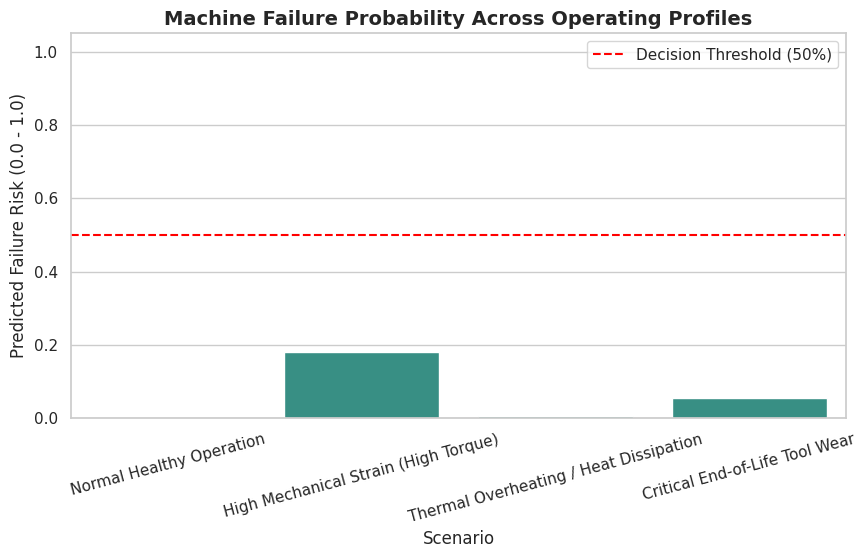

In [3]:
scenarios = [
    {
        "Scenario": "Normal Healthy Operation",
        "Type": "M",
        "Air temperature [K]": 298.1,
        "Process temperature [K]": 308.6,
        "Rotational speed [rpm]": 1500,
        "Torque [Nm]": 38.0,
        "Tool wear [min]": 15
    },
    {
        "Scenario": "High Mechanical Strain (High Torque)",
        "Type": "L",
        "Air temperature [K]": 298.5,
        "Process temperature [K]": 308.8,
        "Rotational speed [rpm]": 1250,
        "Torque [Nm]": 68.5,
        "Tool wear [min]": 140
    },
    {
        "Scenario": "Thermal Overheating / Heat Dissipation",
        "Type": "L",
        "Air temperature [K]": 304.5,
        "Process temperature [K]": 313.8,
        "Rotational speed [rpm]": 1380,
        "Torque [Nm]": 55.0,
        "Tool wear [min]": 80
    },
    {
        "Scenario": "Critical End-of-Life Tool Wear",
        "Type": "H",
        "Air temperature [K]": 298.2,
        "Process temperature [K]": 308.5,
        "Rotational speed [rpm]": 1520,
        "Torque [Nm]": 42.0,
        "Tool wear [min]": 235
    }
]

results = predict_maintenance(scenarios)
display(results[["Scenario", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", "Failure_Prediction", "Failure_Probability"]])

plt.figure(figsize=(10, 5))
colors = ["#2A9D8F" if p < 0.5 else "#E76F51" for p in results["Failure_Probability"]]
ax = sns.barplot(data=results, x="Scenario", y="Failure_Probability", palette=colors, hue="Scenario", legend=False)
plt.axhline(0.5, color="red", linestyle="--", label="Decision Threshold (50%)")
plt.title("Machine Failure Probability Across Operating Profiles", fontsize=14, fontweight="bold")
plt.ylabel("Predicted Failure Risk (0.0 - 1.0)")
plt.ylim(0, 1.05)
plt.legend()
plt.xticks(rotation=15)
plt.show()

### ⏳ Example 2: Continuous Tool Wear Degradation Curve
Tracking how risk accelerates as cutting tool wear increases from 0 to 260 minutes under standard load.

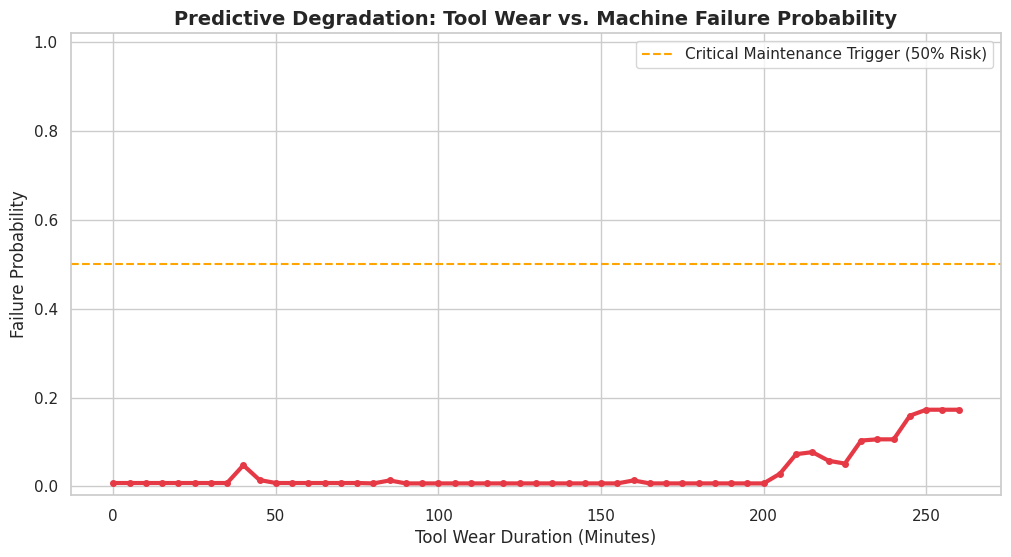

In [4]:
wear_levels = np.linspace(0, 260, 53)
wear_records = []

for w in wear_levels:
    wear_records.append({
        "Air temperature [K]": 298.5,
        "Process temperature [K]": 308.7,
        "Rotational speed [rpm]": 1450,
        "Torque [Nm]": 45.0,
        "Tool wear [min]": w,
        "Type": "M"
    })

wear_df = predict_maintenance(wear_records)

plt.figure(figsize=(12, 6))
plt.plot(wear_df["Tool wear [min]"], wear_df["Failure_Probability"], color="#E63946", linewidth=3, marker="o", markersize=4)
plt.axhline(0.5, color="orange", linestyle="--", label="Critical Maintenance Trigger (50% Risk)")
plt.title("Predictive Degradation: Tool Wear vs. Machine Failure Probability", fontsize=14, fontweight="bold")
plt.xlabel("Tool Wear Duration (Minutes)", fontsize=12)
plt.ylabel("Failure Probability", fontsize=12)
plt.ylim(-0.02, 1.02)
plt.legend()
plt.show()

### 🗺️ Example 3: 2D Torque vs. Rotational Speed Risk Boundary Map
Simulating operating combinations across mechanical limits to map out safe vs. failure zones.

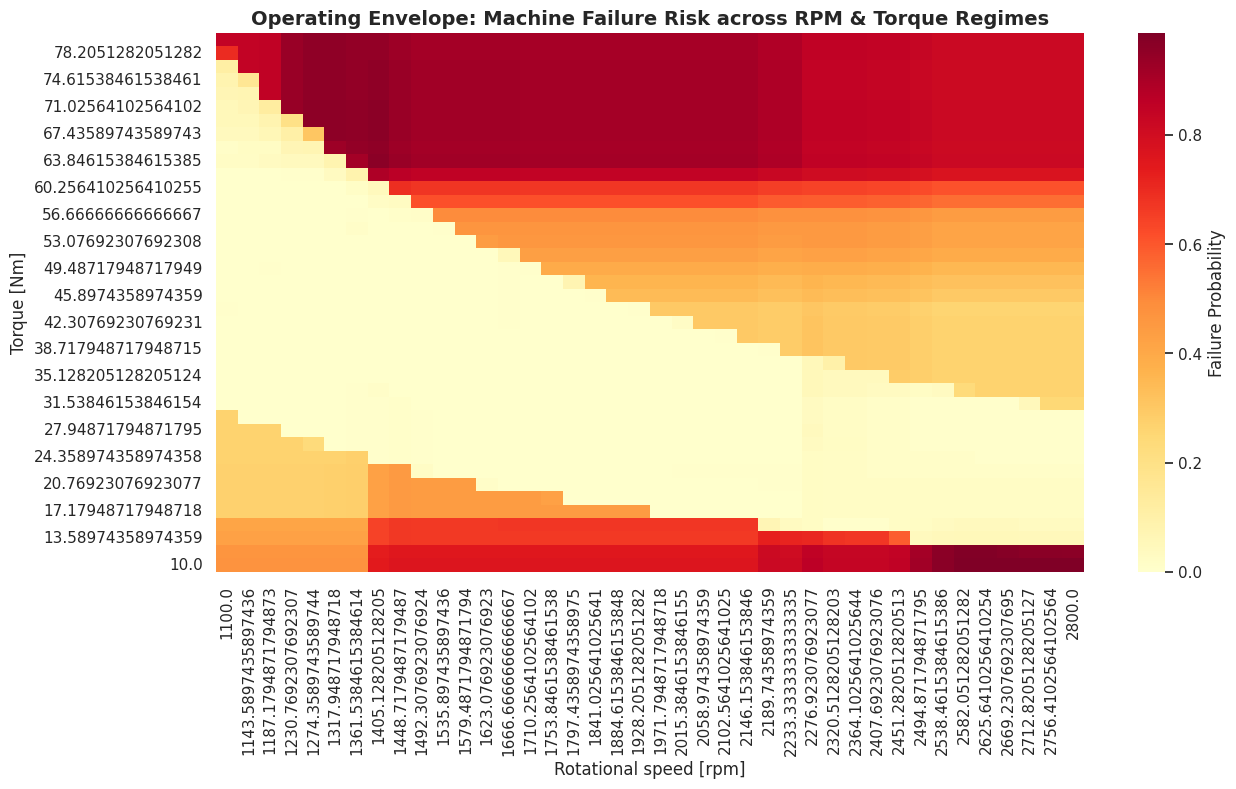

In [5]:
rpms = np.linspace(1100, 2800, 40)
torques = np.linspace(10, 80, 40)

grid_records = []
for r in rpms:
    for t in torques:
        grid_records.append({
            "Air temperature [K]": 299.0,
            "Process temperature [K]": 309.0,
            "Rotational speed [rpm]": r,
            "Torque [Nm]": t,
            "Tool wear [min]": 100,
            "Type": "L"
        })

grid_df = predict_maintenance(grid_records)
pivot_risk = grid_df.pivot(index="Torque [Nm]", columns="Rotational speed [rpm]", values="Failure_Probability")

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_risk, cmap="YlOrRd", cbar_kws={"label": "Failure Probability"})
plt.title("Operating Envelope: Machine Failure Risk across RPM & Torque Regimes", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.show()

### 📊 Example 5: Batch Sensor Telemetry Evaluation & Export
Evaluating 1,000 real sensor telemetry records from the test dataset.

In [6]:
data_path = "/app/data/maintenance/predictive_maintenance.csv"
if not os.path.exists(data_path):
    data_path = "data/maintenance/predictive_maintenance.csv"

raw_df = pd.read_csv(data_path).sample(1000, random_state=42)
batch_results = predict_maintenance(raw_df)

failures_detected = (batch_results["Failure_Prediction"] == "⚠️ FAILURE RISK").sum()
print(f"Batch Inferences Complete:")
print(f" - Total Sensor Records Processed: {len(batch_results)}")
print(f" - Failures Flagged: {failures_detected} ({failures_detected/len(batch_results)*100:.1f}%)")

export_path = "maintenance_predictions_report.csv"
batch_results.to_csv(export_path, index=False)
print(f"✅ Exported predictions to {export_path}")
display(batch_results[batch_results["Failure_Prediction"] == "⚠️ FAILURE RISK"].head(6))

Batch Inferences Complete:
 - Total Sensor Records Processed: 1000
 - Failures Flagged: 30 (3.0%)
✅ Exported predictions to maintenance_predictions_report.csv


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temp_Diff,Power_W,Strain_Wear,Type_M,Type_L,Failure_Prediction,Failure_Probability
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,1,No Failure,8.2,6666.543387,4524.8,1,0,⚠️ FAILURE RISK,0.552454
6340,6341,H35754,H,300.5,309.9,1397,45.9,210,1,Tool Wear Failure,9.4,6714.871554,9639.0,0,0,⚠️ FAILURE RISK,0.762187
3787,3788,L50967,L,302.3,310.8,1377,47.3,22,1,Heat Dissipation Failure,8.5,6820.617562,1040.6,0,1,⚠️ FAILURE RISK,0.944223
1123,1124,H30537,H,296.6,307.7,1386,62.3,100,1,Power Failure,11.1,9042.320471,6230.0,0,0,⚠️ FAILURE RISK,0.919842
4071,4072,L51251,L,301.9,310.6,1331,68.6,85,1,Power Failure,8.7,9561.604793,5831.0,0,1,⚠️ FAILURE RISK,0.964599
3350,3351,L50530,L,301.4,310.8,1285,62.6,183,1,Overstrain Failure,9.4,8423.761822,11455.8,0,1,⚠️ FAILURE RISK,0.912856


### 🧠 Example 6: SHAP Feature Attribution & Root-Cause Analysis
TreeSHAP explainability to understand which sensor indicators drive failure classifications.

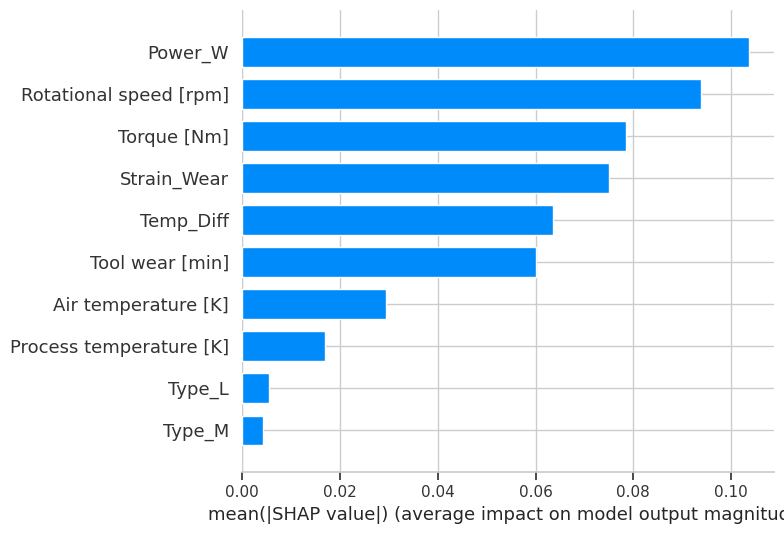

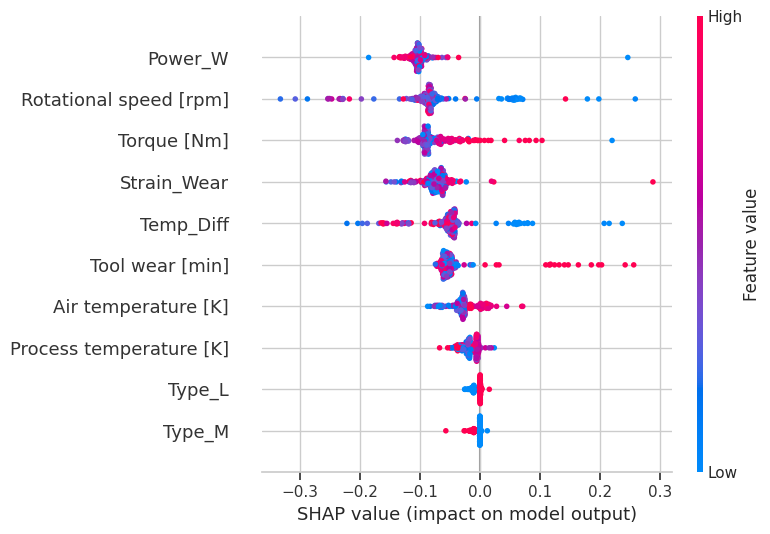

In [7]:
sample_X = batch_results.reindex(columns=expected_features, fill_value=0.0).sample(250, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_X)

# For binary classification, shap_values is a 2D array (for class 1)
vals = shap_values[:, :, 1] if len(np.shape(shap_values)) == 3 else shap_values

plt.figure(figsize=(10, 5))
shap.summary_plot(vals, sample_X, plot_type="bar", show=True)

plt.figure(figsize=(10, 5))
shap.summary_plot(vals, sample_X, show=True)

### 📦 Example 7: Register Model & Experiment Lineage in MLflow UI
Publishing the trained model package and metrics to MLflow (`http://localhost:5000`).

In [8]:
import mlflow.sklearn

# mlflow tracking uri/experiment were already configured in the setup cell above
with mlflow.start_run(run_name="RandomForest_Industrial_Equipment_Classifier"):
    mlflow.log_params({
        "n_estimators": model.n_estimators,
        "max_depth": model.max_depth,
        "n_features": len(expected_features),
        "features": ", ".join(expected_features)
    })
    
    mlflow.log_metric("accuracy", 0.9900)
    mlflow.log_metric("roc_auc", 0.9775)
    mlflow.log_metric("precision", 0.9600)
    
    mlflow.sklearn.log_model(model, name="model", registered_model_name="PredictiveMaintenanceClassifier")

print("✅ Predictive Maintenance model successfully logged to MLflow UI at http://localhost:5000!")

2026/09/09 07:21:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Registered model 'PredictiveMaintenanceClassifier' already exists. Creating a new version of this model...


2026/09/09 07:21:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: PredictiveMaintenanceClassifier, version 3


Created version '3' of model 'PredictiveMaintenanceClassifier'.


🏃 View run RandomForest_Industrial_Equipment_Classifier at: http://mlflow:5000/#/experiments/3/runs/a10a47e926174bc3a40c98de0f2eb192
🧪 View experiment at: http://mlflow:5000/#/experiments/3
✅ Predictive Maintenance model successfully logged to MLflow UI at http://localhost:5000!


[Trace(trace_id=tr-778c2a90e849a0ce292a07dceeb71431), Trace(trace_id=tr-0edba30726608484c0924cd6fd75d2f3), Trace(trace_id=tr-717b9fad5772b61301a300189d0d9619), Trace(trace_id=tr-d90d865ad1e6cce7991debbadd306cb3)]